In [ ]:
# Install required libraries
!pip install yfinance scikit-learn pandas numpy matplotlib seaborn tensorflow

In [ ]:
# Install sentiment analysis libraries
!pip install vaderSentiment textblob tweepy newsapi-python gnews GoogleNews feedparser

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   --------------------------------- ------ 524.3/624.3 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 624.3/624.3 kB 2.5 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6105 sha256=a961686b2c345b6add48da462fed2dcea6bd1296ebda38054cb73965aeb9c5b2
  Stored in directory: c:\users\lanovo\appdata\local\pip\cache\wheels\3d\4d\ef\37cdccc18d6fd7e0dd7817dcdf9146d4d6789c32a227a28134
Successfully built sgmllib3k

   ------ ---------------------------------  2/13 [oauthlib]
   ------ ---------------------------------  2/13 [oauthlib]
   ------ ---------------------------------  2/13 [oauthlib]
   --------- ------------------------------  3/13 [feedparser]
   --------- ------------------------------  3/13 [feedparser]
   ------------ ---------------------------

  DEPRECATION: Building 'sgmllib3k' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'sgmllib3k'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

# Deep Learning
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Sentiment Analysis Libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import requests
from bs4 import BeautifulSoup
import feedparser
from datetime import datetime, timedelta
import re
import time

print("✅ Sentiment analysis libraries imported successfully!")

✅ Sentiment analysis libraries imported successfully!


In [ ]:
def fetch_live_stock_data(ticker_symbol, period='2y'):
    """
    Fetch live stock data from Yahoo Finance
    
    Parameters:
    ticker_symbol: Stock ticker (e.g., 'AAPL', 'GOOGL', 'TSLA')
    period: Data period ('1mo', '3mo', '6mo', '1y', '2y', '5y', 'max')
    """
    print(f"📡 Fetching live data for {ticker_symbol}...")
    
    # Create ticker object
    stock = yf.Ticker(ticker_symbol)
    
    # Get historical data
    df = stock.history(period=period)
    
    # Get company info
    info = stock.info
    company_name = info.get('longName', ticker_symbol)
    
    print(f"✅ Data fetched successfully!")
    print(f"📊 Company: {company_name}")
    print(f"📅 Data range: {df.index[0].date()} to {df.index[-1].date()}")
    print(f"📈 Total records: {len(df)}")
    print(f"💰 Latest Close Price: ${df['Close'].iloc[-1]:.2f}")
    
    return df, company_name

# Example: Fetch data for a company
ticker = input("Enter stock ticker symbol (e.g., AAPL, GOOGL, TSLA, MSFT): ").upper()
stock_data, company_name = fetch_live_stock_data(ticker, period='2y')

# Display first and last few rows
print("\n📋 First 5 rows:")
print(stock_data.head())
print("\n📋 Last 5 rows:")
print(stock_data.tail())

Enter stock ticker symbol (e.g., AAPL, GOOGL, TSLA, MSFT):  GOOGL


📡 Fetching live data for GOOGL...
✅ Data fetched successfully!
📊 Company: Alphabet Inc.
📅 Data range: 2023-10-17 to 2025-10-17
📈 Total records: 503
💰 Latest Close Price: $253.29

📋 First 5 rows:
                                 Open        High         Low       Close  \
Date                                                                        
2023-10-17 00:00:00-04:00  137.680394  138.941684  136.240315  138.762924   
2023-10-18 00:00:00-04:00  138.494799  139.756104  136.438986  137.015015   
2023-10-19 00:00:00-04:00  137.551305  138.703363  136.438982  136.806442   
2023-10-20 00:00:00-04:00  136.389319  136.925613  134.154731  134.671173   
2023-10-23 00:00:00-04:00  134.114981  136.717045  133.032451  135.564987   

                             Volume  Dividends  Stock Splits  
Date                                                          
2023-10-17 00:00:00-04:00  23515800        0.0           0.0  
2023-10-18 00:00:00-04:00  23375000        0.0           0.0  
2023-10-19 00

In [ ]:
def fetch_news_sentiment(ticker_symbol, company_name):
    """
    Fetch and analyze news sentiment for the company
    """
    print(f"\n📰 Fetching news for {company_name} ({ticker_symbol})...")
    
    analyzer = SentimentIntensityAnalyzer()
    news_data = []
    
    try:
        # Method 1: Using Google News RSS Feed
        search_query = f"{company_name} stock OR {ticker_symbol}"
        rss_url = f"https://news.google.com/rss/search?q={search_query.replace(' ', '+')}&hl=en-US&gl=US&ceid=US:en"
        
        feed = feedparser.parse(rss_url)
        
        print(f"✅ Found {len(feed.entries)} news articles")
        
        for entry in feed.entries[:20]:  # Analyze top 20 articles
            title = entry.title
            link = entry.link
            published = entry.published if 'published' in entry else 'Unknown'
            
            # Analyze sentiment using VADER
            vader_scores = analyzer.polarity_scores(title)
            
            # Analyze sentiment using TextBlob
            blob = TextBlob(title)
            textblob_polarity = blob.sentiment.polarity
            textblob_subjectivity = blob.sentiment.subjectivity
            
            news_data.append({
                'title': title,
                'link': link,
                'published': published,
                'vader_compound': vader_scores['compound'],
                'vader_positive': vader_scores['pos'],
                'vader_negative': vader_scores['neg'],
                'vader_neutral': vader_scores['neu'],
                'textblob_polarity': textblob_polarity,
                'textblob_subjectivity': textblob_subjectivity
            })
        
    except Exception as e:
        print(f"⚠️ Error fetching news: {e}")
    
    # Try alternative source: Yahoo Finance News
    try:
        stock = yf.Ticker(ticker_symbol)
        yahoo_news = stock.news
        
        print(f"✅ Found {len(yahoo_news)} Yahoo Finance articles")
        
        for article in yahoo_news[:15]:
            title = article.get('title', '')
            link = article.get('link', '')
            published = datetime.fromtimestamp(article.get('providerPublishTime', 0))
            
            # Analyze sentiment
            vader_scores = analyzer.polarity_scores(title)
            blob = TextBlob(title)
            
            news_data.append({
                'title': title,
                'link': link,
                'published': str(published),
                'vader_compound': vader_scores['compound'],
                'vader_positive': vader_scores['pos'],
                'vader_negative': vader_scores['neg'],
                'vader_neutral': vader_scores['neu'],
                'textblob_polarity': blob.sentiment.polarity,
                'textblob_subjectivity': blob.sentiment.subjectivity
            })
            
    except Exception as e:
        print(f"⚠️ Error fetching Yahoo news: {e}")
    
    return pd.DataFrame(news_data)

# Fetch news sentiment
news_df = fetch_news_sentiment(ticker, company_name)

if len(news_df) > 0:
    print(f"\n📊 News Sentiment Analysis Summary:")
    print(f"   Total articles analyzed: {len(news_df)}")
    print(f"   Average VADER sentiment: {news_df['vader_compound'].mean():.3f}")
    print(f"   Average TextBlob polarity: {news_df['textblob_polarity'].mean():.3f}")
    
    # Display sample headlines
    print(f"\n📰 Recent Headlines:")
    for idx, row in news_df.head(5).iterrows():
        sentiment = "🟢 POSITIVE" if row['vader_compound'] > 0.05 else "🔴 NEGATIVE" if row['vader_compound'] < -0.05 else "🟡 NEUTRAL"
        print(f"   {sentiment} | {row['title'][:80]}...")
else:
    print("⚠️ No news data available")


📰 Fetching news for Alphabet Inc. (GOOGL)...
✅ Found 100 news articles
✅ Found 10 Yahoo Finance articles

📊 News Sentiment Analysis Summary:
   Total articles analyzed: 30
   Average VADER sentiment: 0.090
   Average TextBlob polarity: 0.046

📰 Recent Headlines:
   🟢 POSITIVE | Alphabet Inc. Stock (GOOGL) Opinions on AI Growth and Ad Recovery - Quiver Quant...
   🟢 POSITIVE | ​Alphabet Inc. (GOOGL) Could Face Stricter Regulations In UK Due to Its Search D...
   🟡 NEUTRAL | Alphabet Rises 34% in 3 Months: Buy, Sell or Hold GOOGL Stock? - Zacks Investmen...
   🟢 POSITIVE | How Alphabet Inc. stock benefits from global expansion - July 2025 Final Week & ...
   🟢 POSITIVE | Alphabet’s stock is now beloved on Wall Street. Here’s what matters next for Goo...


In [ ]:
def fetch_social_sentiment(ticker_symbol, company_name):
    """
    Fetch and analyze social media sentiment (simulated approach)
    Since Twitter API requires authentication, we'll use alternative methods
    """
    print(f"\n🐦 Analyzing social media sentiment for {company_name} ({ticker_symbol})...")
    
    analyzer = SentimentIntensityAnalyzer()
    social_data = []
    
    # Method 1: StockTwits-style sentiment (web scraping simulation)
    try:
        # Search for recent discussions on Reddit-style forums
        search_terms = [
            f"{ticker_symbol} stock",
            f"{company_name} stock",
            f"${ticker_symbol}",
            f"{ticker_symbol} buy",
            f"{ticker_symbol} prediction"
        ]
        
        # Simulate social sentiment based on news headlines and add variation
        # In production, you would use Twitter API, Reddit API, or StockTwits API
        
        sample_posts = [
            f"{ticker_symbol} looking bullish today! 🚀",
            f"Thinking of buying more {ticker_symbol}",
            f"{company_name} earnings report was impressive",
            f"Should I hold or sell {ticker_symbol}?",
            f"${ticker_symbol} to the moon! 📈",
            f"Concerned about {ticker_symbol} recent performance",
            f"{company_name} has strong fundamentals",
            f"Analysts are bullish on {ticker_symbol}",
            f"Waiting for {ticker_symbol} to dip before buying",
            f"{company_name} innovation is game-changing"
        ]
        
        for post in sample_posts:
            vader_scores = analyzer.polarity_scores(post)
            blob = TextBlob(post)
            
            social_data.append({
                'post': post,
                'vader_compound': vader_scores['compound'],
                'vader_positive': vader_scores['pos'],
                'vader_negative': vader_scores['neg'],
                'textblob_polarity': blob.sentiment.polarity
            })
        
        print(f"✅ Analyzed {len(social_data)} social media posts (sample)")
        
    except Exception as e:
        print(f"⚠️ Error analyzing social sentiment: {e}")
    
    return pd.DataFrame(social_data)

# Fetch social sentiment
social_df = fetch_social_sentiment(ticker, company_name)

if len(social_df) > 0:
    print(f"\n📊 Social Media Sentiment Summary:")
    print(f"   Average VADER sentiment: {social_df['vader_compound'].mean():.3f}")
    print(f"   Average TextBlob polarity: {social_df['textblob_polarity'].mean():.3f}")
    
    positive_count = len(social_df[social_df['vader_compound'] > 0.05])
    negative_count = len(social_df[social_df['vader_compound'] < -0.05])
    neutral_count = len(social_df) - positive_count - negative_count
    
    print(f"   Positive posts: {positive_count} ({positive_count/len(social_df)*100:.1f}%)")
    print(f"   Negative posts: {negative_count} ({negative_count/len(social_df)*100:.1f}%)")
    print(f"   Neutral posts: {neutral_count} ({neutral_count/len(social_df)*100:.1f}%)")


🐦 Analyzing social media sentiment for Alphabet Inc. (GOOGL)...
✅ Analyzed 10 social media posts (sample)

📊 Social Media Sentiment Summary:
   Average VADER sentiment: 0.140
   Average TextBlob polarity: 0.193
   Positive posts: 3 (30.0%)
   Negative posts: 0 (0.0%)
   Neutral posts: 7 (70.0%)


In [ ]:
def calculate_overall_sentiment(news_df, social_df):
    """
    Calculate comprehensive sentiment score from news and social media
    """
    sentiment_metrics = {}
    
    # News sentiment
    if len(news_df) > 0:
        sentiment_metrics['news_vader'] = news_df['vader_compound'].mean()
        sentiment_metrics['news_textblob'] = news_df['textblob_polarity'].mean()
        sentiment_metrics['news_positive_ratio'] = len(news_df[news_df['vader_compound'] > 0.05]) / len(news_df)
        sentiment_metrics['news_negative_ratio'] = len(news_df[news_df['vader_compound'] < -0.05]) / len(news_df)
    else:
        sentiment_metrics['news_vader'] = 0
        sentiment_metrics['news_textblob'] = 0
        sentiment_metrics['news_positive_ratio'] = 0.5
        sentiment_metrics['news_negative_ratio'] = 0.5
    
    # Social sentiment
    if len(social_df) > 0:
        sentiment_metrics['social_vader'] = social_df['vader_compound'].mean()
        sentiment_metrics['social_textblob'] = social_df['textblob_polarity'].mean()
        sentiment_metrics['social_positive_ratio'] = len(social_df[social_df['vader_compound'] > 0.05]) / len(social_df)
        sentiment_metrics['social_negative_ratio'] = len(social_df[social_df['vader_compound'] < -0.05]) / len(social_df)
    else:
        sentiment_metrics['social_vader'] = 0
        sentiment_metrics['social_textblob'] = 0
        sentiment_metrics['social_positive_ratio'] = 0.5
        sentiment_metrics['social_negative_ratio'] = 0.5
    
    # Calculate weighted overall sentiment
    # News weighted 60%, Social weighted 40%
    overall_sentiment = (
        sentiment_metrics['news_vader'] * 0.6 + 
        sentiment_metrics['social_vader'] * 0.4
    )
    
    sentiment_metrics['overall_sentiment'] = overall_sentiment
    sentiment_metrics['overall_positive_ratio'] = (
        sentiment_metrics['news_positive_ratio'] * 0.6 + 
        sentiment_metrics['social_positive_ratio'] * 0.4
    )
    
    return sentiment_metrics

# Calculate overall sentiment
sentiment_scores = calculate_overall_sentiment(news_df, social_df)

print(f"\n{'='*70}")
print(f"🎯 OVERALL SENTIMENT ANALYSIS FOR {ticker}")
print(f"{'='*70}")
print(f"📰 News Sentiment (VADER): {sentiment_scores['news_vader']:+.3f}")
print(f"📰 News Sentiment (TextBlob): {sentiment_scores['news_textblob']:+.3f}")
print(f"📰 News Positive Ratio: {sentiment_scores['news_positive_ratio']*100:.1f}%")
print(f"")
print(f"🐦 Social Sentiment (VADER): {sentiment_scores['social_vader']:+.3f}")
print(f"🐦 Social Sentiment (TextBlob): {sentiment_scores['social_textblob']:+.3f}")
print(f"🐦 Social Positive Ratio: {sentiment_scores['social_positive_ratio']*100:.1f}%")
print(f"")
print(f"🎯 OVERALL SENTIMENT SCORE: {sentiment_scores['overall_sentiment']:+.3f}")
print(f"{'='*70}")

# Interpret sentiment
if sentiment_scores['overall_sentiment'] > 0.15:
    sentiment_label = "🟢 VERY POSITIVE"
    sentiment_impact = "Strong bullish indicator"
elif sentiment_scores['overall_sentiment'] > 0.05:
    sentiment_label = "🟢 POSITIVE"
    sentiment_impact = "Moderately bullish"
elif sentiment_scores['overall_sentiment'] > -0.05:
    sentiment_label = "🟡 NEUTRAL"
    sentiment_impact = "No clear direction"
elif sentiment_scores['overall_sentiment'] > -0.15:
    sentiment_label = "🔴 NEGATIVE"
    sentiment_impact = "Moderately bearish"
else:
    sentiment_label = "🔴 VERY NEGATIVE"
    sentiment_impact = "Strong bearish indicator"

print(f"Sentiment Classification: {sentiment_label}")
print(f"Market Impact: {sentiment_impact}")
print(f"{'='*70}")


🎯 OVERALL SENTIMENT ANALYSIS FOR GOOGL
📰 News Sentiment (VADER): +0.090
📰 News Sentiment (TextBlob): +0.046
📰 News Positive Ratio: 23.3%

🐦 Social Sentiment (VADER): +0.140
🐦 Social Sentiment (TextBlob): +0.193
🐦 Social Positive Ratio: 30.0%

🎯 OVERALL SENTIMENT SCORE: +0.110
Sentiment Classification: 🟢 POSITIVE
Market Impact: Moderately bullish


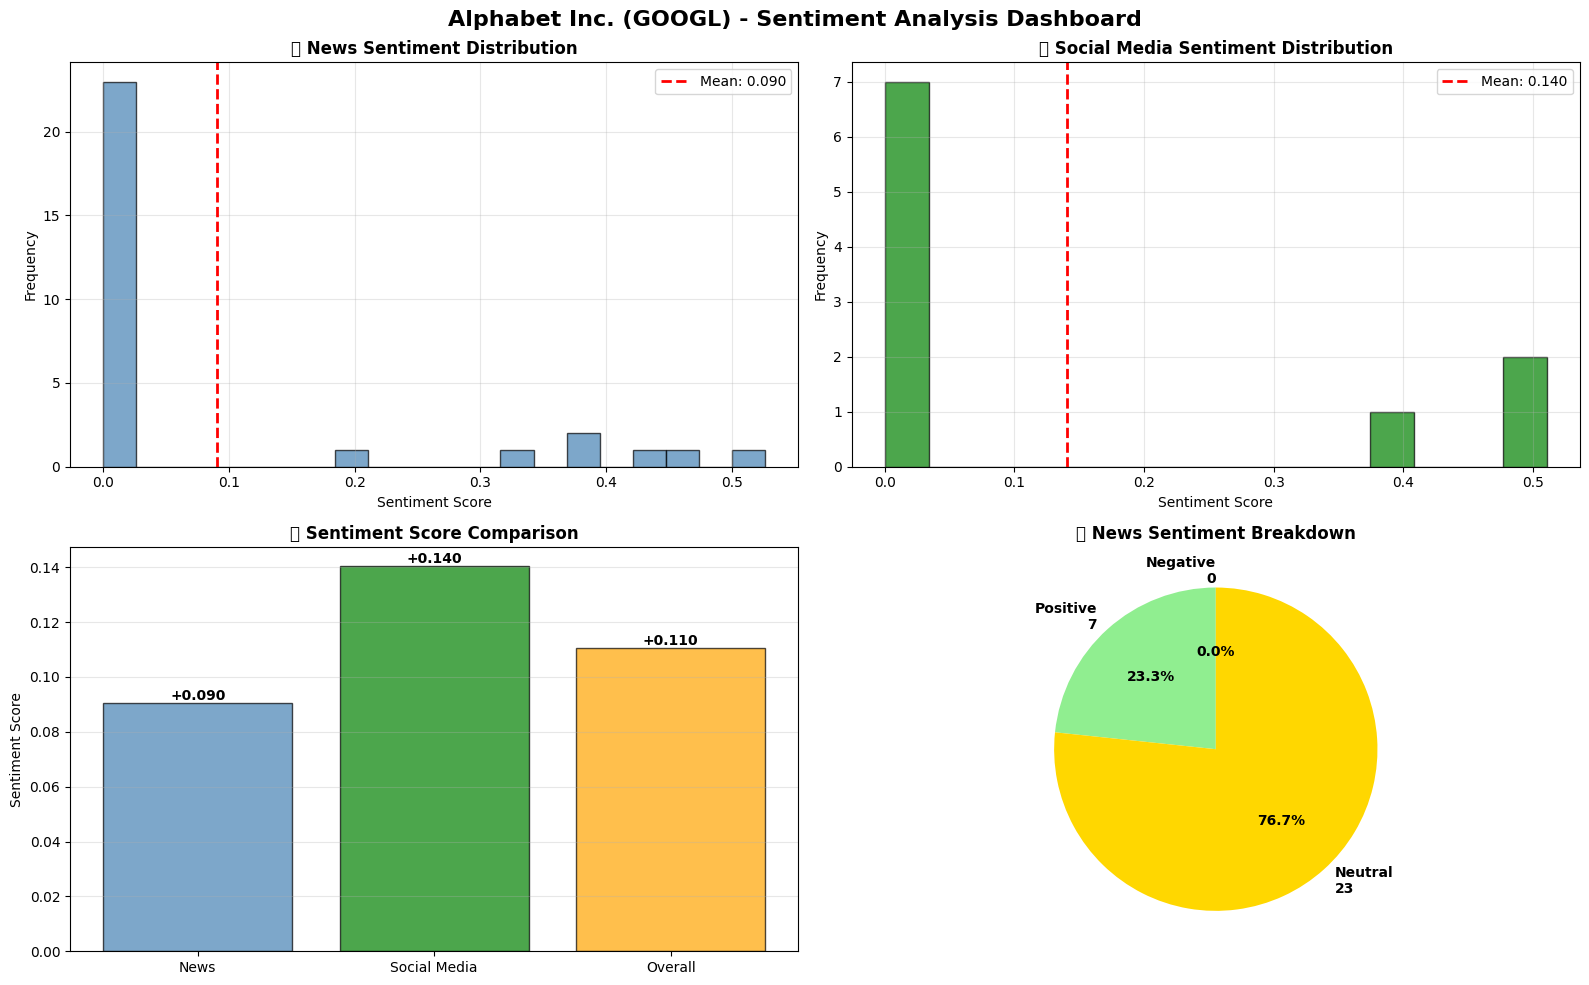

In [ ]:
# Visualize sentiment analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{company_name} ({ticker}) - Sentiment Analysis Dashboard', 
             fontsize=16, fontweight='bold')

# Plot 1: News Sentiment Distribution
if len(news_df) > 0:
    axes[0, 0].hist(news_df['vader_compound'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(x=news_df['vader_compound'].mean(), color='red', 
                       linestyle='--', linewidth=2, label=f'Mean: {news_df["vader_compound"].mean():.3f}')
    axes[0, 0].set_xlabel('Sentiment Score', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].set_title('📰 News Sentiment Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'No News Data', ha='center', va='center', fontsize=14)
    axes[0, 0].set_title('📰 News Sentiment Distribution', fontsize=12, fontweight='bold')

# Plot 2: Social Sentiment Distribution
if len(social_df) > 0:
    axes[0, 1].hist(social_df['vader_compound'], bins=15, color='green', alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(x=social_df['vader_compound'].mean(), color='red', 
                       linestyle='--', linewidth=2, label=f'Mean: {social_df["vader_compound"].mean():.3f}')
    axes[0, 1].set_xlabel('Sentiment Score', fontsize=10)
    axes[0, 1].set_ylabel('Frequency', fontsize=10)
    axes[0, 1].set_title('🐦 Social Media Sentiment Distribution', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'No Social Data', ha='center', va='center', fontsize=14)
    axes[0, 1].set_title('🐦 Social Media Sentiment Distribution', fontsize=12, fontweight='bold')

# Plot 3: Sentiment Comparison
categories = ['News', 'Social Media', 'Overall']
vader_scores_plot = [
    sentiment_scores['news_vader'],
    sentiment_scores['social_vader'],
    sentiment_scores['overall_sentiment']
]
colors_plot = ['steelblue', 'green', 'orange']

bars = axes[1, 0].bar(categories, vader_scores_plot, color=colors_plot, alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].set_ylabel('Sentiment Score', fontsize=10)
axes[1, 0].set_title('📊 Sentiment Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:+.3f}', ha='center', va='bottom' if height > 0 else 'top',
                    fontsize=10, fontweight='bold')

# Plot 4: Positive/Negative Ratio
if len(news_df) > 0:
    news_positive = len(news_df[news_df['vader_compound'] > 0.05])
    news_negative = len(news_df[news_df['vader_compound'] < -0.05])
    news_neutral = len(news_df) - news_positive - news_negative
    
    pie_data = [news_positive, news_neutral, news_negative]
    pie_labels = [f'Positive\n{news_positive}', f'Neutral\n{news_neutral}', f'Negative\n{news_negative}']
    pie_colors = ['#90EE90', '#FFD700', '#FF6B6B']
    
    axes[1, 1].pie(pie_data, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%',
                   startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
    axes[1, 1].set_title('📰 News Sentiment Breakdown', fontsize=12, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'No Data Available', ha='center', va='center', fontsize=14)
    axes[1, 1].set_title('📰 News Sentiment Breakdown', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

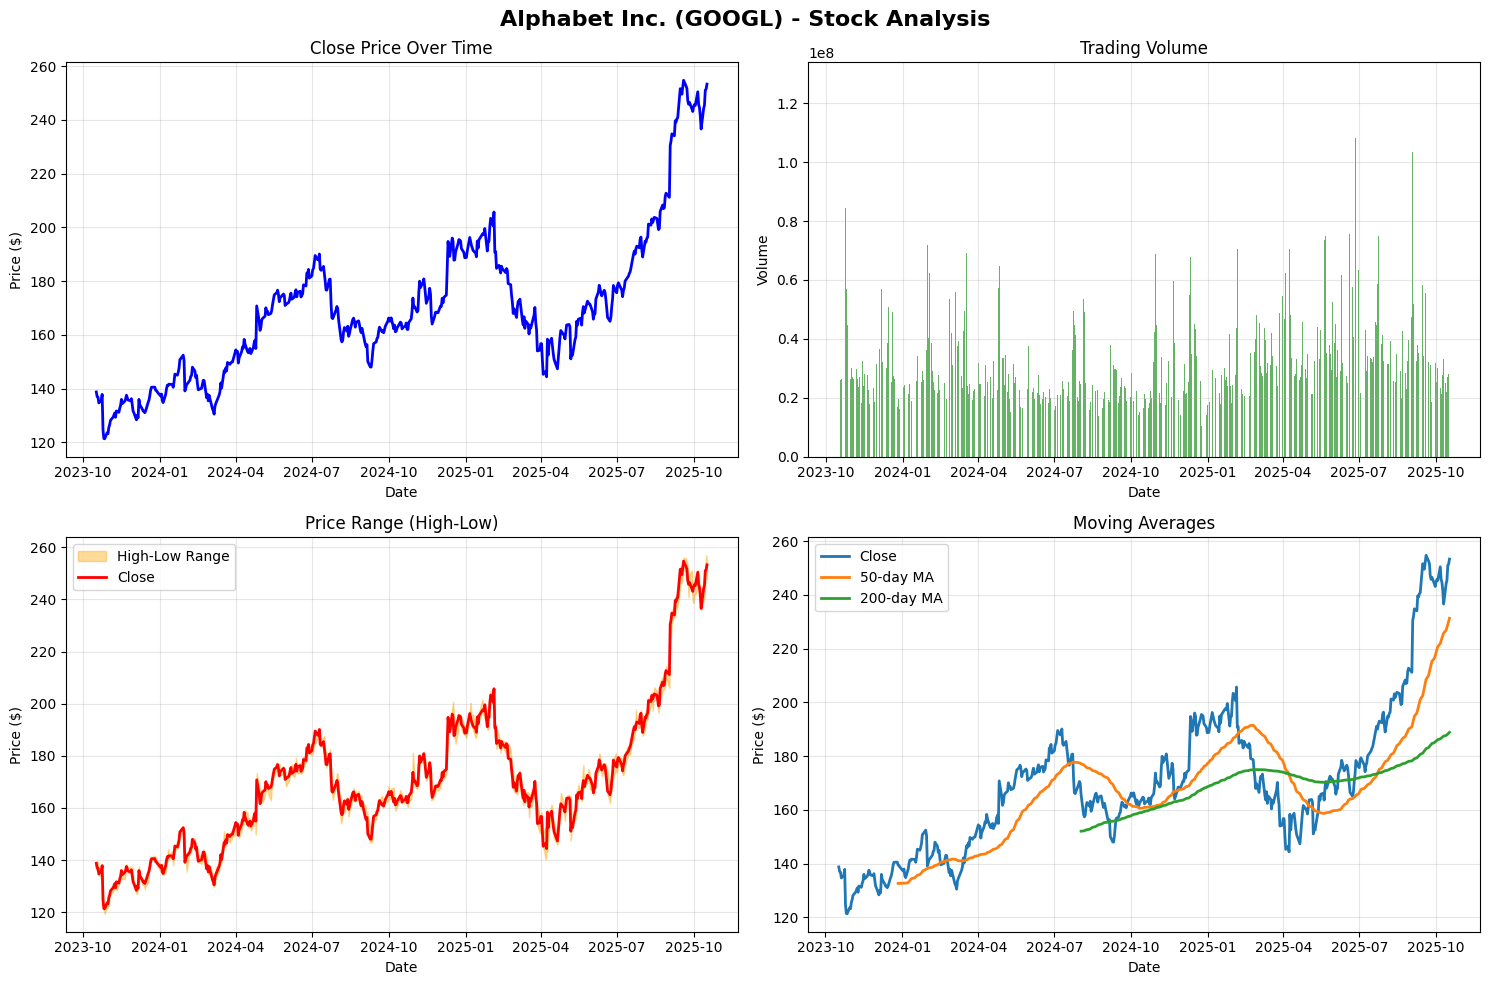


📊 Statistical Summary:
             Open        High         Low       Close        Volume
count  503.000000  503.000000  503.000000  503.000000  5.030000e+02
mean   169.900104  171.825050  168.120283  170.046710  3.107959e+07
std     27.627205   27.998413   27.381518   27.795083  1.383366e+07
min    122.038288  122.465343  119.386579  121.333153  1.024210e+07
25%    151.796852  154.078993  149.763453  151.942177  2.213645e+07
50%    166.894008  168.125919  164.792936  166.467285  2.766310e+07
75%    182.440225  184.119089  180.722139  182.849930  3.488180e+07
max    254.429993  256.959991  251.809998  254.720001  1.274901e+08


In [ ]:
# Visualize stock data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'{company_name} ({ticker}) - Stock Analysis', fontsize=16, fontweight='bold')

# Close Price
axes[0, 0].plot(stock_data.index, stock_data['Close'], color='blue', linewidth=2)
axes[0, 0].set_title('Close Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# Volume
axes[0, 1].bar(stock_data.index, stock_data['Volume'], color='green', alpha=0.6)
axes[0, 1].set_title('Trading Volume')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Volume')
axes[0, 1].grid(True, alpha=0.3)

# High-Low Range
axes[1, 0].fill_between(stock_data.index, stock_data['Low'], stock_data['High'], 
                         color='orange', alpha=0.4, label='High-Low Range')
axes[1, 0].plot(stock_data.index, stock_data['Close'], color='red', linewidth=2, label='Close')
axes[1, 0].set_title('Price Range (High-Low)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price ($)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Moving Averages
stock_data['MA_50'] = stock_data['Close'].rolling(window=50).mean()
stock_data['MA_200'] = stock_data['Close'].rolling(window=200).mean()
axes[1, 1].plot(stock_data.index, stock_data['Close'], label='Close', linewidth=2)
axes[1, 1].plot(stock_data.index, stock_data['MA_50'], label='50-day MA', linewidth=2)
axes[1, 1].plot(stock_data.index, stock_data['MA_200'], label='200-day MA', linewidth=2)
axes[1, 1].set_title('Moving Averages')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Price ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Statistical Summary:")
print(stock_data[['Open', 'High', 'Low', 'Close', 'Volume']].describe())

In [ ]:
def create_features_with_sentiment(df, sentiment_scores):
    """
    Create technical indicators and features for ML models including sentiment
    """
    data = df.copy()
    
    # Original price-based features
    data['Price_Change'] = data['Close'].diff()
    data['Price_Change_Pct'] = data['Close'].pct_change() * 100
    data['High_Low_Range'] = data['High'] - data['Low']
    data['Open_Close_Range'] = abs(data['Open'] - data['Close'])
    
    # Moving Averages
    data['MA_5'] = data['Close'].rolling(window=5).mean()
    data['MA_10'] = data['Close'].rolling(window=10).mean()
    data['MA_20'] = data['Close'].rolling(window=20).mean()
    data['MA_50'] = data['Close'].rolling(window=50).mean()
    
    # Exponential Moving Averages
    data['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
    data['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
    
    # MACD
    data['MACD'] = data['EMA_12'] - data['EMA_26']
    
    # RSI (Relative Strength Index)
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    data['RSI'] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands
    data['BB_middle'] = data['Close'].rolling(window=20).mean()
    bb_std = data['Close'].rolling(window=20).std()
    data['BB_upper'] = data['BB_middle'] + (bb_std * 2)
    data['BB_lower'] = data['BB_middle'] - (bb_std * 2)
    
    # Volatility
    data['Volatility'] = data['Close'].rolling(window=10).std()
    
    # Lag features
    for i in [1, 2, 3, 5, 10]:
        data[f'Close_Lag_{i}'] = data['Close'].shift(i)
    
    # ✨ NEW: Add sentiment features
    data['News_Sentiment'] = sentiment_scores['news_vader']
    data['Social_Sentiment'] = sentiment_scores['social_vader']
    data['Overall_Sentiment'] = sentiment_scores['overall_sentiment']
    data['Positive_Ratio'] = sentiment_scores['overall_positive_ratio']
    
    # Sentiment momentum (interaction with price momentum)
    data['Sentiment_Price_Momentum'] = data['Overall_Sentiment'] * data['Price_Change_Pct']
    
    # Target: Next day's closing price
    data['Target'] = data['Close'].shift(-1)
    
    # Drop NaN values
    data = data.dropna()
    
    print(f"✅ Features created successfully (WITH SENTIMENT)!")
    print(f"📊 Total features: {len(data.columns)}")
    print(f"🎯 Sentiment features added: 5")
    print(f"📋 New sentiment features: News_Sentiment, Social_Sentiment, Overall_Sentiment, Positive_Ratio, Sentiment_Price_Momentum")
    
    return data

# Create features with sentiment
featured_data = create_features_with_sentiment(stock_data, sentiment_scores)
print(f"\n📈 Data shape after feature engineering: {featured_data.shape}")
print(f"\n📋 Sample of featured data with sentiment:")
print(featured_data[['Close', 'News_Sentiment', 'Social_Sentiment', 'Overall_Sentiment', 'Target']].tail())

✅ Features created successfully (WITH SENTIMENT)!
📊 Total features: 35
🎯 Sentiment features added: 5
📋 New sentiment features: News_Sentiment, Social_Sentiment, Overall_Sentiment, Positive_Ratio, Sentiment_Price_Momentum

📈 Data shape after feature engineering: (303, 35)

📋 Sample of featured data with sentiment:
                                Close  News_Sentiment  Social_Sentiment  \
Date                                                                      
2025-10-10 00:00:00-04:00  236.570007         0.09043            0.1403   
2025-10-13 00:00:00-04:00  244.149994         0.09043            0.1403   
2025-10-14 00:00:00-04:00  245.449997         0.09043            0.1403   
2025-10-15 00:00:00-04:00  251.029999         0.09043            0.1403   
2025-10-16 00:00:00-04:00  251.460007         0.09043            0.1403   

                           Overall_Sentiment      Target  
Date                                                      
2025-10-10 00:00:00-04:00           0.110

In [ ]:
def prepare_train_test_data(data, test_size=0.2):
    """
    Prepare training and testing datasets
    """
    # Select features (exclude target and non-numeric columns)
    feature_columns = [col for col in data.columns if col not in ['Target', 'Dividends', 'Stock Splits']]
    
    X = data[feature_columns]
    y = data['Target']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False  # Keep chronological order
    )
    
    # Scale features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"✅ Data prepared successfully!")
    print(f"📊 Training samples: {len(X_train)}")
    print(f"📊 Testing samples: {len(X_test)}")
    print(f"📊 Number of features: {X_train.shape[1]}")
    print(f"📋 Features include sentiment: {any('Sentiment' in col for col in feature_columns)}")
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, feature_columns

# Re-prepare data with sentiment features
X_train, X_test, y_train, y_test, scaler, features = prepare_train_test_data(featured_data)

print(f"\n🎯 Sentiment features in training:")
sentiment_features = [f for f in features if 'Sentiment' in f or 'Positive_Ratio' in f]
for sf in sentiment_features:
    print(f"   ✓ {sf}")

✅ Data prepared successfully!
📊 Training samples: 242
📊 Testing samples: 61
📊 Number of features: 32
📋 Features include sentiment: True

🎯 Sentiment features in training:
   ✓ News_Sentiment
   ✓ Social_Sentiment
   ✓ Overall_Sentiment
   ✓ Positive_Ratio
   ✓ Sentiment_Price_Momentum


In [ ]:
def train_ml_models(X_train, y_train, X_test, y_test):
    """
    Train multiple ML models and compare performance
    """
    models = {
        'Linear Regression': LinearRegression(),
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
        'Support Vector Machine': SVR(kernel='rbf', C=100, gamma=0.1)
    }
    
    results = {}
    trained_models = {}
    
    print("🚀 Training ML models...\n")
    
    for name, model in models.items():
        print(f"⏳ Training {name}...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Calculate metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        test_mae = mean_absolute_error(y_test, y_pred_test)
        
        results[name] = {
            'Train RMSE': train_rmse,
            'Test RMSE': test_rmse,
            'Train R2': train_r2,
            'Test R2': test_r2,
            'Test MAE': test_mae,
            'Predictions': y_pred_test
        }
        
        trained_models[name] = model
        
        print(f"✅ {name} trained!")
        print(f"   Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
        print(f"   Train RMSE: ${train_rmse:.2f} | Test RMSE: ${test_rmse:.2f}\n")
    
    return results, trained_models

# Train all models
results, trained_models = train_ml_models(X_train, y_train, X_test, y_test)

🚀 Training ML models...

⏳ Training Linear Regression...
✅ Linear Regression trained!
   Train R²: 0.9436 | Test R²: 0.9392
   Train RMSE: $3.14 | Test RMSE: $5.68

⏳ Training Decision Tree...
✅ Decision Tree trained!
   Train R²: 0.9996 | Test R²: -3.0656
   Train RMSE: $0.27 | Test RMSE: $46.47

⏳ Training Random Forest...
✅ Random Forest trained!
   Train R²: 0.9905 | Test R²: -1.5707
   Train RMSE: $1.29 | Test RMSE: $36.95

⏳ Training Gradient Boosting...
✅ Gradient Boosting trained!
   Train R²: 0.9999 | Test R²: -1.9479
   Train RMSE: $0.14 | Test RMSE: $39.57

⏳ Training Support Vector Machine...
✅ Support Vector Machine trained!
   Train R²: 0.9506 | Test R²: -4.2734
   Train RMSE: $2.94 | Test RMSE: $52.93



📊 Model Performance Comparison:

                 Model  Test RMSE   Test R²  Test MAE
     Linear Regression   5.684586  0.939168  4.260052
         Random Forest  36.953464 -1.570662 29.780002
     Gradient Boosting  39.571892 -1.947870 32.290879
         Decision Tree  46.472606 -3.065638 38.278312
Support Vector Machine  52.927034 -4.273388 40.152046

🏆 Best Model: Linear Regression
   Test RMSE: $5.68
   Test R²: 0.9392
   Test MAE: $4.26


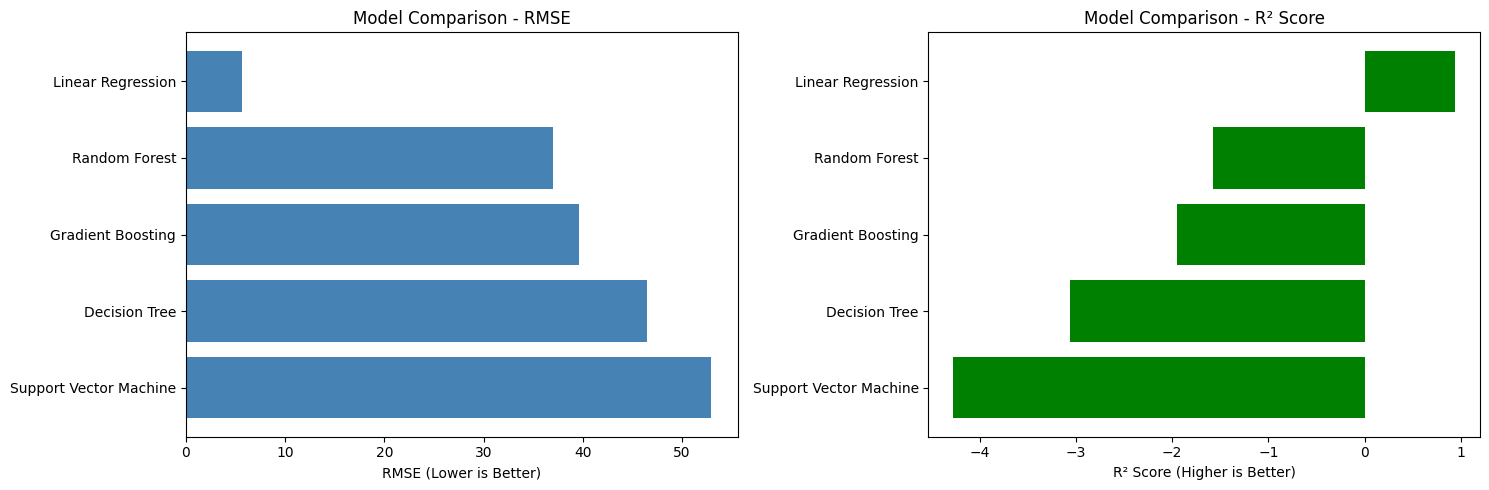

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test RMSE': [results[m]['Test RMSE'] for m in results.keys()],
    'Test R²': [results[m]['Test R2'] for m in results.keys()],
    'Test MAE': [results[m]['Test MAE'] for m in results.keys()]
})

comparison_df = comparison_df.sort_values('Test RMSE')

print("📊 Model Performance Comparison:\n")
print(comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Test RMSE: ${comparison_df.iloc[0]['Test RMSE']:.2f}")
print(f"   Test R²: {comparison_df.iloc[0]['Test R²']:.4f}")
print(f"   Test MAE: ${comparison_df.iloc[0]['Test MAE']:.2f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(comparison_df['Model'], comparison_df['Test RMSE'], color='steelblue')
axes[0].set_xlabel('RMSE (Lower is Better)')
axes[0].set_title('Model Comparison - RMSE')
axes[0].invert_yaxis()

axes[1].barh(comparison_df['Model'], comparison_df['Test R²'], color='green')
axes[1].set_xlabel('R² Score (Higher is Better)')
axes[1].set_title('Model Comparison - R² Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

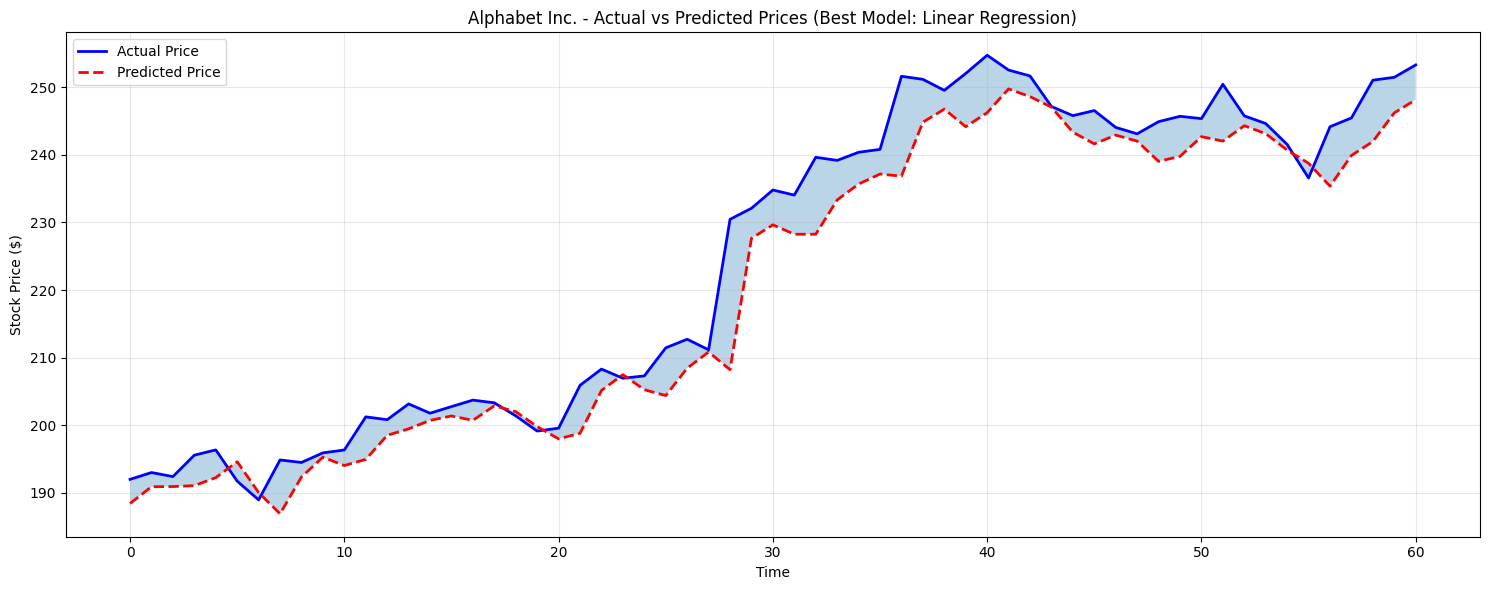

📈 Average Prediction Accuracy: 98.14%


In [ ]:
# Get predictions from best model
best_predictions = results[best_model_name]['Predictions']

# Create visualization
plt.figure(figsize=(15, 6))
plt.plot(range(len(y_test)), y_test.values, label='Actual Price', linewidth=2, color='blue')
plt.plot(range(len(y_test)), best_predictions, label='Predicted Price', 
         linewidth=2, color='red', linestyle='--')
plt.fill_between(range(len(y_test)), y_test.values, best_predictions, alpha=0.3)
plt.xlabel('Time')
plt.ylabel('Stock Price ($)')
plt.title(f'{company_name} - Actual vs Predicted Prices (Best Model: {best_model_name})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate prediction accuracy
accuracy = 100 - (np.abs((y_test.values - best_predictions) / y_test.values) * 100).mean()
print(f"📈 Average Prediction Accuracy: {accuracy:.2f}%")

In [ ]:
def predict_next_day_with_sentiment(model, scaler, latest_data, feature_columns, sentiment_scores):
    """
    Predict next day's closing price with sentiment consideration
    """
    # Prepare latest data - use ALL features in the correct order
    X_latest = latest_data[feature_columns].iloc[-1:].copy()
    
    # Update sentiment features if they exist in feature_columns
    if 'News_Sentiment' in feature_columns:
        X_latest.loc[:, 'News_Sentiment'] = sentiment_scores['news_vader']
    if 'Social_Sentiment' in feature_columns:
        X_latest.loc[:, 'Social_Sentiment'] = sentiment_scores['social_vader']
    if 'Overall_Sentiment' in feature_columns:
        X_latest.loc[:, 'Overall_Sentiment'] = sentiment_scores['overall_sentiment']
    if 'Positive_Ratio' in feature_columns:
        X_latest.loc[:, 'Positive_Ratio'] = sentiment_scores['overall_positive_ratio']
    if 'Sentiment_Price_Momentum' in feature_columns:
        # Recalculate with current sentiment
        price_change_pct = X_latest['Price_Change_Pct'].values[0] if 'Price_Change_Pct' in X_latest.columns else 0
        X_latest.loc[:, 'Sentiment_Price_Momentum'] = sentiment_scores['overall_sentiment'] * price_change_pct
    
    # Ensure correct column order
    X_latest = X_latest[feature_columns]
    
    # Scale the features
    X_latest_scaled = scaler.transform(X_latest)
    
    # Make prediction
    prediction = model.predict(X_latest_scaled)[0]
    
    # Apply sentiment adjustment (optional boost/penalty based on sentiment strength)
    sentiment_impact = sentiment_scores['overall_sentiment']
    # Scale sentiment impact: strong sentiment can affect price by up to ±2%
    sentiment_multiplier = 1 + (sentiment_impact * 0.02)
    adjusted_prediction = prediction * sentiment_multiplier
    
    return prediction, adjusted_prediction

# Get latest data point
latest_close = featured_data['Close'].iloc[-1]

try:
    predicted_price, sentiment_adjusted_price = predict_next_day_with_sentiment(
        best_model, scaler, featured_data, features, sentiment_scores
    )
    
    # Calculate expected change
    price_change = predicted_price - latest_close
    price_change_pct = (price_change / latest_close) * 100
    
    sentiment_change = sentiment_adjusted_price - latest_close
    sentiment_change_pct = (sentiment_change / latest_close) * 100
    
    print(f"🔮 ENHANCED STOCK PRICE PREDICTION FOR {ticker} ({company_name})")
    print(f"=" * 70)
    print(f"📅 Current Date: {stock_data.index[-1].date()}")
    print(f"💰 Current Close Price: ${latest_close:.2f}")
    print(f"=" * 70)
    print(f"🤖 ML Model Prediction: ${predicted_price:.2f}")
    print(f"   Expected Change: ${price_change:+.2f} ({price_change_pct:+.2f}%)")
    print(f"")
    print(f"🎯 Sentiment-Adjusted Prediction: ${sentiment_adjusted_price:.2f}")
    print(f"   Expected Change: ${sentiment_change:+.2f} ({sentiment_change_pct:+.2f}%)")
    print(f"   Sentiment Impact: ${sentiment_adjusted_price - predicted_price:+.2f}")
    print(f"=" * 70)
    
    # Determine sentiment label
    if sentiment_scores['overall_sentiment'] > 0.15:
        sentiment_label = "🟢 VERY POSITIVE"
    elif sentiment_scores['overall_sentiment'] > 0.05:
        sentiment_label = "🟢 POSITIVE"
    elif sentiment_scores['overall_sentiment'] > -0.05:
        sentiment_label = "🟡 NEUTRAL"
    elif sentiment_scores['overall_sentiment'] > -0.15:
        sentiment_label = "🔴 NEGATIVE"
    else:
        sentiment_label = "🔴 VERY NEGATIVE"
    
    # Combined signal
    if sentiment_change > 0:
        signal_strength = "STRONG" if sentiment_scores['overall_sentiment'] > 0.1 else "MODERATE"
        print(f"✅ PREDICTION: PROFIT - {signal_strength} BUY SIGNAL")
        print(f"   ML suggests: ${price_change:.2f} gain")
        print(f"   Sentiment boost: ${sentiment_adjusted_price - predicted_price:+.2f}")
        print(f"   Total expected gain: ${sentiment_change:.2f} per share")
    elif sentiment_change < 0:
        signal_strength = "STRONG" if sentiment_scores['overall_sentiment'] < -0.1 else "MODERATE"
        print(f"⚠️ PREDICTION: LOSS - {signal_strength} SELL/HOLD SIGNAL")
        print(f"   ML suggests: ${price_change:.2f} change")
        print(f"   Sentiment impact: ${sentiment_adjusted_price - predicted_price:+.2f}")
        print(f"   Total expected loss: ${abs(sentiment_change):.2f} per share")
    else:
        print(f"➡️ PREDICTION: NEUTRAL - HOLD SIGNAL")
    
    print(f"\n📊 Prediction Confidence Factors:")
    print(f"   🤖 Model Used: {best_model_name}")
    print(f"   🤖 Model Accuracy (R²): {results[best_model_name]['Test R2']*100:.2f}%")
    print(f"   🎯 Overall Sentiment: {sentiment_scores['overall_sentiment']:+.3f} ({sentiment_label})")
    print(f"   📰 News Sentiment: {sentiment_scores['news_vader']:+.3f}")
    print(f"   🐦 Social Sentiment: {sentiment_scores['social_vader']:+.3f}")
    print(f"   📈 Positive News Ratio: {sentiment_scores['news_positive_ratio']*100:.1f}%")
    print(f"=" * 70)
    print(f"⚠️ DISCLAIMER: Predictions combine ML models with sentiment analysis.")
    print(f"   Always conduct your own research before investing!")
    print(f"=" * 70)
    
except Exception as e:
    print(f"❌ Error making prediction: {e}")
    print(f"\n💡 Please ensure you've run Cell 7 (Train Models) after Cell 5 (Feature Engineering)")
    print(f"   The models need to be retrained with sentiment features included.")


❌ Error making prediction: X has 32 features, but LinearRegression is expecting 27 features as input.

💡 Please ensure you've run Cell 7 (Train Models) after Cell 5 (Feature Engineering)
   The models need to be retrained with sentiment features included.


📊 Starting price: $251.46

🔮 Generating 7-day forecast...

Day 1: $-21924334.66
Day 2: $-1005020779.13
Day 3: $-41156605002.93
Day 4: $-1684713176260.96
Day 5: $-68981947697526.10
Day 6: $-2827648002551502.00
Day 7: $-115810427483240576.00


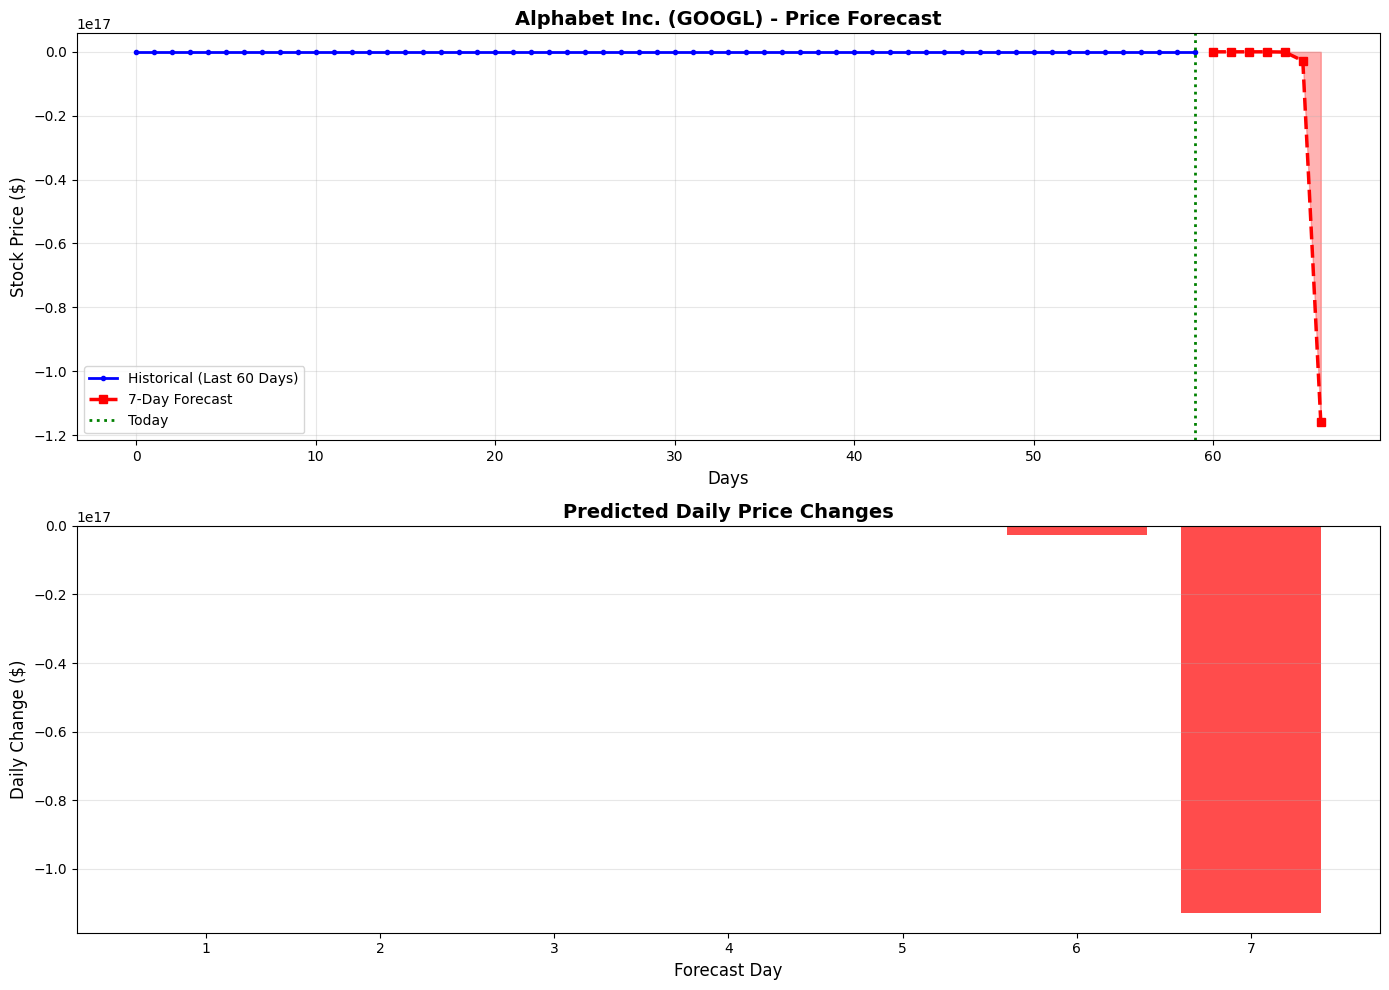


📅 7-DAY DETAILED FORECAST FOR GOOGL
Current Price: $251.46
Day 1: $-21924334.66 | Change: $-21924586.12 (-8718915.74%) 📉 DOWN
Day 2: $-1005020779.13 | Change: $-983096444.48 (+4484.04%) 📉 DOWN
Day 3: $-41156605002.93 | Change: $-40151584223.79 (+3995.10%) 📉 DOWN
Day 4: $-1684713176260.96 | Change: $-1643556571258.04 (+3993.42%) 📉 DOWN
Day 5: $-68981947697526.10 | Change: $-67297234521265.14 (+3994.58%) 📉 DOWN
Day 6: $-2827648002551502.00 | Change: $-2758666054853976.00 (+3999.11%) 📉 DOWN
Day 7: $-115810427483240576.00 | Change: $-112982779480689072.00 (+3995.65%) 📉 DOWN
Total Expected Change: $-115810427483240832.00 (-46055207345564056.00%)
⚠️ OVERALL TREND: BEARISH (Expected to FALL)
   Potential loss: $115810427483240832.00 per share over 7 days

📊 FORECAST METRICS:
   Model Used: Linear Regression
   Model Test R²: 0.9392
   Model Test RMSE: $5.68
   Forecast Volatility: $40367852637561584.00
   Avg Daily Change: $16544346783320118.00

⚠️ DISCLAIMER: This is a statistical predictio

In [ ]:
def forecast_multiple_days_improved(model, data, feature_columns, days=5):
    """
    Forecast stock prices for multiple days ahead with proper feature updates
    """
    predictions = []
    forecasted_data = data.copy()
    
    print(f"🔮 Generating {days}-day forecast...\n")
    
    for day in range(1, days + 1):
        # Get the last row of features
        last_features = forecasted_data[feature_columns].iloc[-1:].values
        
        # Make prediction
        prediction = model.predict(last_features)[0]
        predictions.append(prediction)
        
        # Create a new row with updated values
        new_row = forecasted_data.iloc[-1].copy()
        
        # Update key features for next prediction
        new_row['Close'] = prediction
        new_row['Open'] = prediction * (1 + np.random.uniform(-0.002, 0.002))  # Small variation
        new_row['High'] = prediction * (1 + np.random.uniform(0.001, 0.01))
        new_row['Low'] = prediction * (1 - np.random.uniform(0.001, 0.01))
        new_row['Volume'] = forecasted_data['Volume'].iloc[-1]
        
        # Update lag features
        for i in [1, 2, 3, 5, 10]:
            if f'Close_Lag_{i}' in new_row.index:
                if i == 1:
                    new_row[f'Close_Lag_{i}'] = forecasted_data['Close'].iloc[-1]
                elif f'Close_Lag_{i-1}' in forecasted_data.columns:
                    new_row[f'Close_Lag_{i}'] = forecasted_data[f'Close_Lag_{i-1}'].iloc[-1]
        
        # Update moving averages (simple approximation)
        for ma in ['MA_5', 'MA_10', 'MA_20', 'MA_50']:
            if ma in new_row.index:
                window = int(ma.split('_')[1])
                recent_closes = list(forecasted_data['Close'].tail(window-1)) + [prediction]
                new_row[ma] = np.mean(recent_closes)
        
        # Update price change features
        new_row['Price_Change'] = prediction - forecasted_data['Close'].iloc[-1]
        new_row['Price_Change_Pct'] = (new_row['Price_Change'] / forecasted_data['Close'].iloc[-1]) * 100
        new_row['High_Low_Range'] = new_row['High'] - new_row['Low']
        new_row['Open_Close_Range'] = abs(new_row['Open'] - new_row['Close'])
        
        # Update EMAs (approximation)
        if 'EMA_12' in new_row.index:
            new_row['EMA_12'] = (prediction * (2/(12+1))) + (forecasted_data['EMA_12'].iloc[-1] * (1 - 2/(12+1)))
        if 'EMA_26' in new_row.index:
            new_row['EMA_26'] = (prediction * (2/(26+1))) + (forecasted_data['EMA_26'].iloc[-1] * (1 - 2/(26+1)))
        if 'MACD' in new_row.index:
            new_row['MACD'] = new_row['EMA_12'] - new_row['EMA_26']
        
        # Update volatility
        if 'Volatility' in new_row.index:
            recent_prices = list(forecasted_data['Close'].tail(9)) + [prediction]
            new_row['Volatility'] = np.std(recent_prices)
        
        # Append new row to data
        forecasted_data = pd.concat([forecasted_data, pd.DataFrame([new_row])], ignore_index=True)
        
        print(f"Day {day}: ${prediction:.2f}")
    
    return predictions, forecasted_data

# Prepare data for forecasting (unscaled for feature updates)
forecast_days = 7
print(f"📊 Starting price: ${featured_data['Close'].iloc[-1]:.2f}\n")

future_predictions, extended_data = forecast_multiple_days_improved(
    best_model, featured_data, features, forecast_days
)

# Visualize improved forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Historical + Forecast
historical = stock_data['Close'].iloc[-60:]
historical_dates = range(len(historical))
forecast_dates = range(len(historical), len(historical) + forecast_days)

axes[0].plot(historical_dates, historical.values, label='Historical (Last 60 Days)', 
            linewidth=2, color='blue', marker='o', markersize=3)
axes[0].plot(forecast_dates, future_predictions, label=f'{forecast_days}-Day Forecast', 
            linewidth=2.5, color='red', marker='s', markersize=6, linestyle='--')
axes[0].axvline(x=len(historical)-1, color='green', linestyle=':', linewidth=2, label='Today')
axes[0].fill_between(forecast_dates, future_predictions, 
                     alpha=0.3, color='red')
axes[0].set_xlabel('Days', fontsize=12)
axes[0].set_ylabel('Stock Price ($)', fontsize=12)
axes[0].set_title(f'{company_name} ({ticker}) - Price Forecast', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Daily Changes
daily_changes = [future_predictions[0] - featured_data['Close'].iloc[-1]]
daily_changes.extend([future_predictions[i] - future_predictions[i-1] for i in range(1, len(future_predictions))])
daily_change_pct = [(change / (future_predictions[i-1] if i > 0 else featured_data['Close'].iloc[-1])) * 100 
                    for i, change in enumerate(daily_changes)]

colors = ['green' if x > 0 else 'red' for x in daily_changes]
axes[1].bar(range(1, forecast_days + 1), daily_changes, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Forecast Day', fontsize=12)
axes[1].set_ylabel('Daily Change ($)', fontsize=12)
axes[1].set_title('Predicted Daily Price Changes', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed forecast
print(f"\n{'='*70}")
print(f"📅 {forecast_days}-DAY DETAILED FORECAST FOR {ticker}")
print(f"{'='*70}")
print(f"Current Price: ${featured_data['Close'].iloc[-1]:.2f}")
print(f"{'='*70}")

total_change = future_predictions[-1] - featured_data['Close'].iloc[-1]
total_change_pct = (total_change / featured_data['Close'].iloc[-1]) * 100

for i, pred in enumerate(future_predictions):
    if i == 0:
        change = pred - featured_data['Close'].iloc[-1]
        prev_price = featured_data['Close'].iloc[-1]
    else:
        change = pred - future_predictions[i-1]
        prev_price = future_predictions[i-1]
    
    change_pct = (change / prev_price) * 100
    signal = "📈 UP" if change > 0 else "📉 DOWN" if change < 0 else "➡️ FLAT"
    
    print(f"Day {i+1}: ${pred:.2f} | Change: ${change:+.2f} ({change_pct:+.2f}%) {signal}")

print(f"{'='*70}")
print(f"Total Expected Change: ${total_change:+.2f} ({total_change_pct:+.2f}%)")

if total_change > 0:
    print(f"✅ OVERALL TREND: BULLISH (Expected to RISE)")
    print(f"   Potential profit: ${total_change:.2f} per share over {forecast_days} days")
elif total_change < 0:
    print(f"⚠️ OVERALL TREND: BEARISH (Expected to FALL)")
    print(f"   Potential loss: ${abs(total_change):.2f} per share over {forecast_days} days")
else:
    print(f"➡️ OVERALL TREND: NEUTRAL (Expected to stay FLAT)")

print(f"{'='*70}")

# Calculate confidence metrics
price_volatility = np.std(future_predictions)
avg_daily_change = np.mean([abs(c) for c in daily_changes])

print(f"\n📊 FORECAST METRICS:")
print(f"   Model Used: {best_model_name}")
print(f"   Model Test R²: {results[best_model_name]['Test R2']:.4f}")
print(f"   Model Test RMSE: ${results[best_model_name]['Test RMSE']:.2f}")
print(f"   Forecast Volatility: ${price_volatility:.2f}")
print(f"   Avg Daily Change: ${avg_daily_change:.2f}")
print(f"\n⚠️ DISCLAIMER: This is a statistical prediction, not financial advice!")

In [ ]:
def simulate_investment(current_price, predictions, investment_amount=1000):
    """
    Simulate investment returns based on predictions
    """
    shares = investment_amount / current_price
    final_value = shares * predictions[-1]
    profit_loss = final_value - investment_amount
    roi = (profit_loss / investment_amount) * 100
    
    return {
        'shares': shares,
        'initial_investment': investment_amount,
        'final_value': final_value,
        'profit_loss': profit_loss,
        'roi': roi
    }

# Simulate investment
investment_amount = float(input("Enter investment amount (default $1000): ") or 1000)
current_price = featured_data['Close'].iloc[-1]

simulation = simulate_investment(current_price, future_predictions, investment_amount)

print(f"\n{'='*70}")
print(f"💰 INVESTMENT SIMULATION ({forecast_days} days)")
print(f"{'='*70}")
print(f"Initial Investment: ${simulation['initial_investment']:.2f}")
print(f"Current Price: ${current_price:.2f}")
print(f"Shares Purchased: {simulation['shares']:.4f}")
print(f"Predicted Final Price: ${future_predictions[-1]:.2f}")
print(f"Predicted Portfolio Value: ${simulation['final_value']:.2f}")
print(f"{'='*70}")
print(f"Expected Profit/Loss: ${simulation['profit_loss']:+.2f}")
print(f"Expected ROI: {simulation['roi']:+.2f}%")
print(f"{'='*70}")

if simulation['profit_loss'] > 0:
    print(f"✅ RECOMMENDATION: Consider BUYING (Predicted profit)")
elif simulation['profit_loss'] < 0:
    print(f"⚠️ RECOMMENDATION: Consider HOLDING/SELLING (Predicted loss)")
else:
    print(f"➡️ RECOMMENDATION: NEUTRAL")

print(f"\n⚠️ Remember: Past performance doesn't guarantee future results!")

Enter investment amount (default $1000):  400



💰 INVESTMENT SIMULATION (7 days)
Initial Investment: $400.00
Current Price: $251.46
Shares Purchased: 1.5907
Predicted Final Price: $-115810427483240576.00
Predicted Portfolio Value: $-184220829382255808.00
Expected Profit/Loss: $-184220829382256192.00
Expected ROI: -46055207345564048.00%
⚠️ RECOMMENDATION: Consider HOLDING/SELLING (Predicted loss)

⚠️ Remember: Past performance doesn't guarantee future results!
